## Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.utils import resample

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import plot_utils  #  --> Here font sizes etc. are defined  

## Import data

In [2]:
df = pd.read_csv("/home/santiagodp/Documents/ML/NY_salaries/cleaned_payroll.csv")
df.info()

# Convert total_income to thousands of dollars (k$)
df['total_income_k'] = df['total_income'] / 1000
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 796275 entries, 0 to 796274
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   fiscal_year          796275 non-null  int64  
 1   agency_name          796275 non-null  str    
 2   work_borough         796275 non-null  str    
 3   last_name            795450 non-null  str    
 4   title_description    796267 non-null  str    
 5   pay_basis            796275 non-null  str    
 6   job_antiquity_years  796275 non-null  float64
 7   regular_hours        796275 non-null  float64
 8   ot_hours             796275 non-null  float64
 9   total_hours          796275 non-null  float64
 10  ot_ratio             796275 non-null  float64
 11  regular_gross_paid   796275 non-null  float64
 12  total_ot_paid        796275 non-null  float64
 13  total_other_pay      796275 non-null  float64
 14  total_income         796275 non-null  float64
dtypes: float64(9), int64(1), str

,fiscal_year,job_antiquity_years,regular_hours,ot_hours,total_hours,ot_ratio,regular_gross_paid,total_ot_paid,total_other_pay,total_income,total_income_k
count,796275.000000,796275.000000,796275.000000,796275.000000,796275.000000,796275.000000,796275.000000,796275.000000,796275.000000,796275.000000,796275.000000
mean,2015.528491,10.431768,1758.785992,156.495340,1915.281333,0.080292,59022.067749,8266.559228,5314.559896,72603.186873,72.603187
std,1.120898,8.986317,446.805376,201.906437,561.231405,0.101468,28919.952731,11749.495493,6459.114448,39030.293942,39.030294
min,2014.000000,0.000000,300.020000,-10.500000,300.020000,-0.022222,3772.000000,-23826.850000,-205816.450000,6000.000000,6.000000
25%,2015.000000,2.376454,1795.000000,0.000000,1824.000000,0.000000,38860.800000,0.000000,626.580000,44402.885000,44.402885
50%,2016.000000,8.815880,1830.000000,61.100000,1950.850000,0.036100,55660.640000,2300.910000,3175.400000,65141.100000,65.141100
75%,2017.000000,16.353183,2085.720000,269.170000,2311.930000,0.137410,77170.505000,12823.795000,8331.510000,101860.970000,101.860970
max,2017.000000,68.410678,4171.430000,2736.670000,4545.470000,1.524607,280294.300000,100158.730000,49820.500000,174999.200000,174.999200


## Salary Distribution Plot - Compare fiscal years

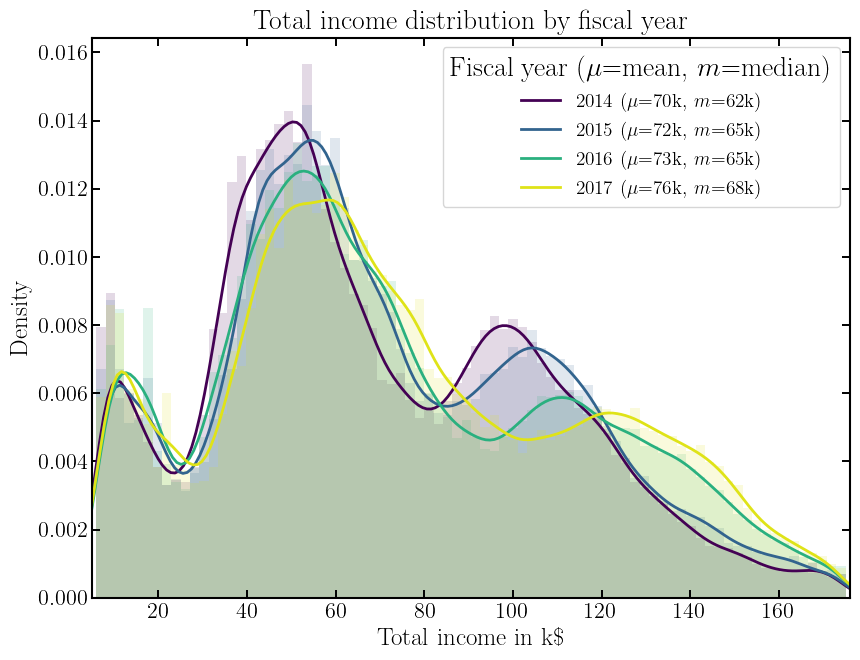

In [3]:
years = sorted(df['fiscal_year'].unique())

# discrete colours sampled from viridis
cmap = plt.cm.viridis
colors = [cmap(i) for i in np.linspace(0.0, 0.95, len(years))]

plt.figure(figsize=(9, 7))

# Store handles for legend
legend_handles = []

for y, c in zip(years, colors):
    subset = df[df['fiscal_year'] == y]['total_income_k']
        
    # Plot histogram 
    plt.hist(subset, bins=80, density=True, alpha=0.15, color=c)
    
    # Plot KDE and store the line object for legend
    kde_line = sns.kdeplot(subset, color=c, linewidth=2, label=f"{y}  ($\mu$={subset.mean():.0f}k, $m$={subset.median():.0f}k)")
    legend_handles.append(kde_line)

plt.xlim(5, 176)

plt.xlabel("Total income in k\$")
plt.ylabel("Density")
plt.title("Total income distribution by fiscal year")
plt.legend(title="Fiscal year ($\mu$=mean, $m$=median)")
plt.tight_layout()
plt.show()

## Salary Distribution Plot - Compare jobs

title_description
police officer         95148
correction officer     34502
firefighter            32121
sanitation worker      25486
school safety agent    20422
community associate    19888
sergeant               16908
Name: count, dtype: int64


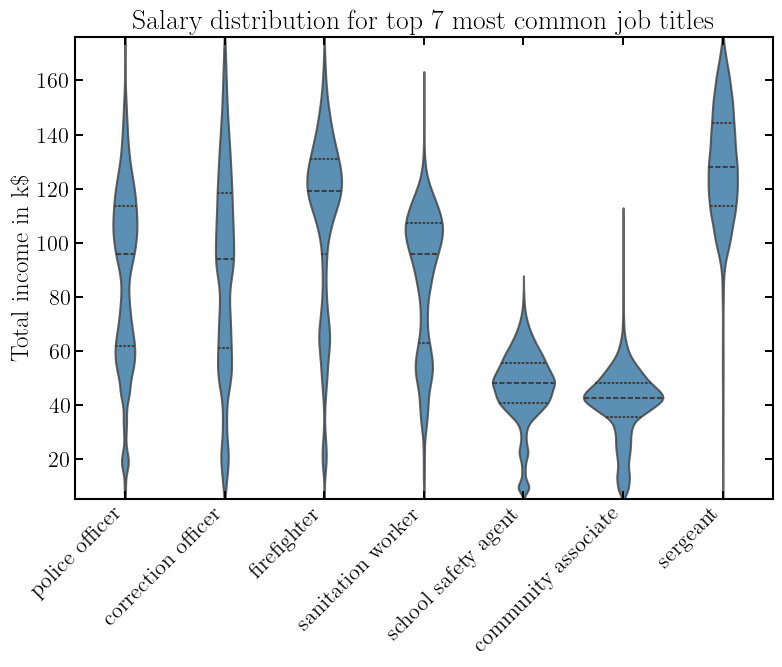

In [4]:
# Obtain the 7 most common job titles by counts
top_titles = (
    df['title_description']
    .value_counts()
    .head(7)
    .index
)

df_top = df[df['title_description'].isin(top_titles)]
print(df_top['title_description'].value_counts())

# Make the plot
plt.figure(figsize=(9,6))

sns.violinplot(
    data=df_top,
    x='title_description',
    y='total_income_k',
    inner='quartile',
    linewidth=1.5,
    order=top_titles,
    alpha=0.8
)


plt.ylim(5, 176)
plt.xticks(rotation=45, ha='right')
plt.title("Salary distribution for top 7 most common job titles")
plt.ylabel("Total income in k\$")
plt.xlabel("")
plt.show()

## Salary Distribution Plot - Compare work boroughs

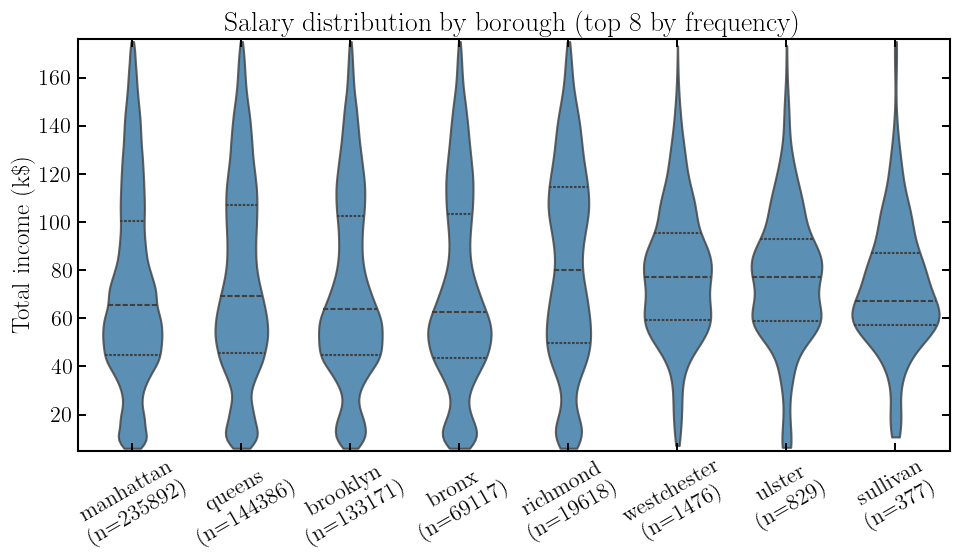

In [5]:
# clean column
df['work_borough'] = (
    df['work_borough']
    .fillna('UNKNOWN')
    .replace('', 'UNKNOWN')
)

# filter valid boroughs
mask_valid = ~df['work_borough'].isin(['OTHER', 'UNKNOWN'])

# get top 8 by frequency
counts = (
    df.loc[mask_valid, 'work_borough']
    .value_counts()
    .head(8)
)

top_boroughs = counts.index.tolist()

# keep only top boroughs
df_top = df[df['work_borough'].isin(top_boroughs)].copy()
df_top['borough_plot'] = df_top['work_borough']

# order by count (descending)
order = counts.index.tolist()

# plot
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df_top,
    x='borough_plot',
    y='total_income_k',
    order=order,
    inner="quartile",       
    linewidth=1.5,
    alpha=0.8,
    cut=0
)

# improve labels with counts
labels = [f"{b}\n(n={counts[b]})" for b in order]
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=30)

plt.ylim(5, 176)
plt.title("Salary distribution by borough (top 8 by frequency)")
plt.ylabel("Total income (k\$)")
plt.xlabel("")
plt.tight_layout()
plt.show()

## Analysis of salary vs hours worked

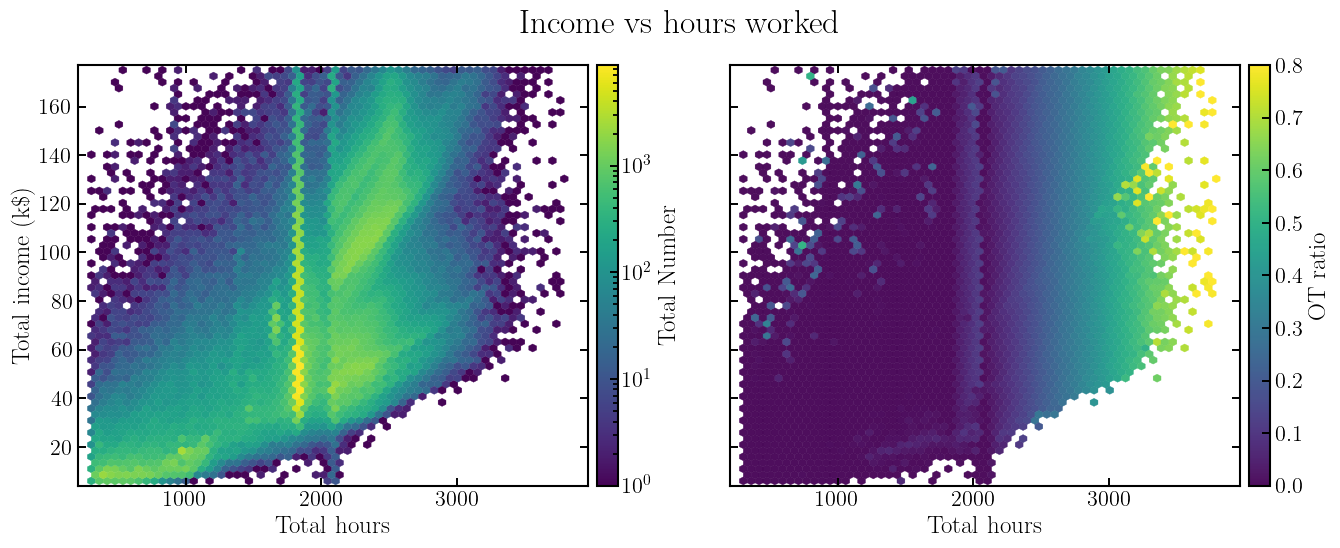

In [6]:
# minimal filtering
df_plot = df[
    (df['total_hours'] < 3800) &
    (df['ot_ratio'].notna())
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharex=True, sharey=True)

# =========================
# LEFT: density
# =========================
hb1 = axes[0].hexbin(
    df_plot['total_hours'],
    df_plot['total_income_k'],
    gridsize=60,
    cmap='viridis',
    bins='log',
    alpha=0.99,
    edgecolors='face',
    linewidths=0.25
)

axes[0].set_xlim(200, )
axes[0].set_ylim(4, 177)
axes[0].set_title("")
axes[0].set_xlabel("Total hours")
axes[0].set_ylabel("Total income (k\$)")

cb1 = fig.colorbar(hb1, ax=axes[0], pad=0.015)
cb1.set_label("Total Number")

# =========================
# RIGHT: OT ratio
# =========================
hb2 = axes[1].hexbin(
    df_plot['total_hours'],
    df_plot['total_income_k'],
    C=df_plot['ot_ratio'],
    reduce_C_function=np.median,
    gridsize=60,
    cmap='viridis',
    vmin=0,
    vmax=0.8,
    alpha=0.95,
    edgecolors='face',
    linewidths=0.25
)

axes[1].set_title("")
axes[1].set_xlabel("Total hours")

cb2 = fig.colorbar(hb2, ax=axes[1], pad=0.015)
cb2.set_label("OT ratio")

fig.suptitle("Income vs hours worked", y=0.93)
plt.tight_layout()
plt.show()

## Analysis of salary vs job antiquity

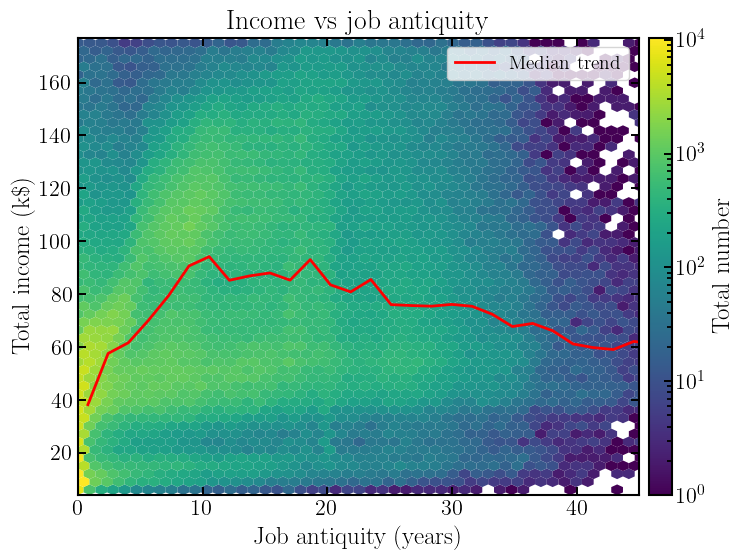

In [7]:
df_plot = df[
    (df['job_antiquity_years'] < 47) &
    (df['total_income_k'] > 0)
].copy()

plt.figure(figsize=(8,6))

hb = plt.hexbin(
    df_plot['job_antiquity_years'],
    df_plot['total_income_k'],
    gridsize=50,
    cmap='viridis',
    bins='log',
    edgecolors='none'
)

# bin antiquity
bins = np.linspace(0, df_plot['job_antiquity_years'].max(), 30)
centers = 0.5 * (bins[:-1] + bins[1:])

median_income = [
    df_plot['total_income_k'][(df_plot['job_antiquity_years'] >= bins[i]) &
             (df_plot['job_antiquity_years'] < bins[i+1])].median()
    for i in range(len(bins)-1)
]

plt.plot(centers, median_income, color='red', lw=2, label='Median trend')
plt.legend()

plt.xlim(0, 45)
plt.ylim(4, 177)
plt.xlabel("Job antiquity (years)")
plt.ylabel("Total income (k\$)")
plt.title("Income vs job antiquity")

cb = plt.colorbar(hb, pad=0.015)
cb.set_label("Total number")

plt.tight_layout()
plt.show()

# Machine Learning model for predicting salaries

## Analyse categories 

In [8]:
def summarize_categorical(df, col, top_n=10):
    print("=" * 50)
    print(f"{col.upper()} — TOP {top_n}")
    print("=" * 50)
    
    counts = df[col].value_counts()
    print(counts.head(top_n))
    
    print("-" * 50)
    print(f"Unique values: {counts.shape[0]}")
    print("\n")

summarize_categorical(df, 'work_borough', 10)
summarize_categorical(df, 'title_description', 20)
summarize_categorical(df, 'agency_name', 20)

WORK_BOROUGH — TOP 10
work_borough
manhattan      235892
UNKNOWN        190712
queens         144386
brooklyn       133171
bronx           69117
richmond        19618
westchester      1476
ulster            829
sullivan          377
delaware          257
Name: count, dtype: int64
--------------------------------------------------
Unique values: 19


TITLE_DESCRIPTION — TOP 20
title_description
police officer                        95148
correction officer                    34502
firefighter                           32121
sanitation worker                     25486
school safety agent                   20422
community associate                   19888
sergeant                              16908
clerical associate                    14608
principal administrative associate    13295
caretaker                             12996
p.o. da det gr3                       12131
job training participant              11512
administrative staff analyst          11031
lieutenant                     

## Prepare data for ML model training

In [9]:
print("=" * 50)
print("STEP 1: DEFINE FEATURES AND TARGET")
print("=" * 50)

# Feature types
numerical_features = ['job_antiquity_years', 'total_hours', 'ot_ratio']
categorical_features = ['fiscal_year', 'agency_name', 'work_borough', 'title_description']

# Combine
features = numerical_features + categorical_features
target = 'total_income_k'

X = df[features].copy()
y = df[target].copy()

print(f"\nTotal samples: {len(X):,}")
print(f"Target: {target} (in thousands of $)")

print(f"\nNumerical features (scaled):")
for f in numerical_features:
    print(f"  - {f}")

print(f"\nCategorical features (one-hot encoded):")
for f in categorical_features:
    print(f"  - {f}")

STEP 1: DEFINE FEATURES AND TARGET

Total samples: 796,275
Target: total_income_k (in thousands of $)

Numerical features (scaled):
  - job_antiquity_years
  - total_hours
  - ot_ratio

Categorical features (one-hot encoded):
  - fiscal_year
  - agency_name
  - work_borough
  - title_description


In [10]:
print("=" * 50)
print("STEP 2: CLASS DISTRIBUTION CHECK")
print("=" * 50)

# Check the distribution after filtering
def check_distribution(df, col, top_n=5):
    print(f"\nTop {top_n} {col} (count and %):")
    
    counts = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    
    for val in counts.head(top_n).index:
        print(f"  {val}: {counts[val]:,} rows ({pct[val]:.1f}%)")

check_distribution(X, 'agency_name')
check_distribution(X, 'title_description')

STEP 2: CLASS DISTRIBUTION CHECK

Top 5 agency_name (count and %):
  POLICE DEPARTMENT: 212,765 rows (26.7%)
  FIRE DEPARTMENT: 64,865 rows (8.1%)
  HRA/DEPT OF SOCIAL SERVICES: 56,989 rows (7.2%)
  NYC HOUSING AUTHORITY: 46,616 rows (5.9%)
  DEPARTMENT OF EDUCATION ADMIN: 46,387 rows (5.8%)

Top 5 title_description (count and %):
  police officer: 95,148 rows (11.9%)
  correction officer: 34,502 rows (4.3%)
  firefighter: 32,121 rows (4.0%)
  sanitation worker: 25,486 rows (3.2%)
  school safety agent: 20,422 rows (2.6%)


In [11]:
print("=" * 50)
print("STEP 3: FILTER AND BALANCE")
print("=" * 50)

# First, filter to agencies with at least 5000 employees (so we don't need to oversample)
min_agency_size = 5000
agencies_to_keep = X['agency_name'].value_counts()[X['agency_name'].value_counts() >= min_agency_size].index

# Filter X and y to only these agencies
X_filtered = X[X['agency_name'].isin(agencies_to_keep)].copy()
y_filtered = y[X_filtered.index].copy()

# Now sample equally from each agency taking 4000 samples per agency
target_samples_per_agency = 4000
balanced_X_list = []
balanced_y_list = []

for agency in X_filtered['agency_name'].unique():
    agency_mask = X_filtered['agency_name'] == agency
    agency_X = X_filtered[agency_mask]
    agency_y = y_filtered[agency_mask]
    
    # Sample without replacement (all agencies here have >= min_agency_size)
    sampled_idx = resample(agency_X.index, 
                           n_samples=target_samples_per_agency, 
                           random_state=42,
                           replace=False)
    
    balanced_X_list.append(X_filtered.loc[sampled_idx])
    balanced_y_list.append(y_filtered.loc[sampled_idx])

X_balanced = pd.concat(balanced_X_list)
y_balanced = pd.concat(balanced_y_list)

print(f"\nOriginal size: {len(X):,} rows")
print(f"After filtering to large agencies with >= {min_agency_size} employees: {len(X_filtered):,} rows")
print(f"Final balanced size: {len(X_balanced):,} rows ({len(X_filtered['agency_name'].unique())} agencies × {target_samples_per_agency} samples)")

STEP 3: FILTER AND BALANCE

Original size: 796,275 rows
After filtering to large agencies with >= 5000 employees: 712,906 rows
Final balanced size: 84,000 rows (21 agencies × 4000 samples)


In [12]:
print("=" * 50)
print("STEP 4: SPLITTING DATA")
print("=" * 50)

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {len(X_train):,} rows")
print(f"Test set size: {len(X_test):,} rows")

STEP 4: SPLITTING DATA

Training set size: 67,200 rows
Test set size: 16,800 rows


In [13]:
print("\n" + "=" * 50)
print("STEP 5: IDENTIFY FEATURE TYPES")
print("=" * 50)

# Data type summary
print("\nData types:")
print(X_train[numerical_features].dtypes.to_string())
print(X_train[categorical_features].dtypes.to_string())

#print("\nSample of training data:")
#print(X_train.head(4))


STEP 5: IDENTIFY FEATURE TYPES

Data types:
job_antiquity_years    float64
total_hours            float64
ot_ratio               float64
fiscal_year          int64
agency_name            str
work_borough           str
title_description      str


In [14]:
print("=" * 50)
print("STEP 6: PREPROCESSING PIPELINE")
print("=" * 50)

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Fit on training data and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Sanity checks
print(f"\nShape after preprocessing:")
print(f"  Training set: {X_train_processed.shape}")
print(f"  Test set: {X_test_processed.shape}")

# Show number of features created (categorical features split into more processed features)
n_numerical = len(numerical_features)
n_categorical = X_train_processed.shape[1] - n_numerical
print(f"\nFeature breakdown:")
print(f"  Original features: {X_train.shape[1]}")
print(f"  Processed features: {X_train_processed.shape[1]}")
print(f"  Expansion factor: {X_train_processed.shape[1] / X_train.shape[1]:.2f}x")

STEP 6: PREPROCESSING PIPELINE

Shape after preprocessing:
  Training set: (67200, 856)
  Test set: (16800, 856)

Feature breakdown:
  Original features: 7
  Processed features: 856
  Expansion factor: 122.29x


In [15]:
print("=" * 50)
print("STEP 7: TRAIN RANDOM FOREST")
print("=" * 50)

# Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1 # Use all CPU cores
)

# Train
rf_model.fit(X_train_processed, y_train)

# Predict
y_pred_train = rf_model.predict(X_train_processed)
y_pred_test = rf_model.predict(X_test_processed)

# Metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# Summary
results_df = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'RMSE (k$)': [train_rmse, test_rmse],
    'MAE (k$)': [train_mae, test_mae],
    'R²': [train_r2, test_r2]
})

display(results_df.round(2))

print(f"\nOverfitting gap (ΔR²): {train_r2 - test_r2:.2f}")

STEP 7: TRAIN RANDOM FOREST


,Dataset,RMSE (k$),MAE (k$),R²
0,Train,17.48,12.28,0.76
1,Test,18.62,13.08,0.73



Overfitting gap (ΔR²): 0.03


STEP 8: FEATURE IMPORTANCE


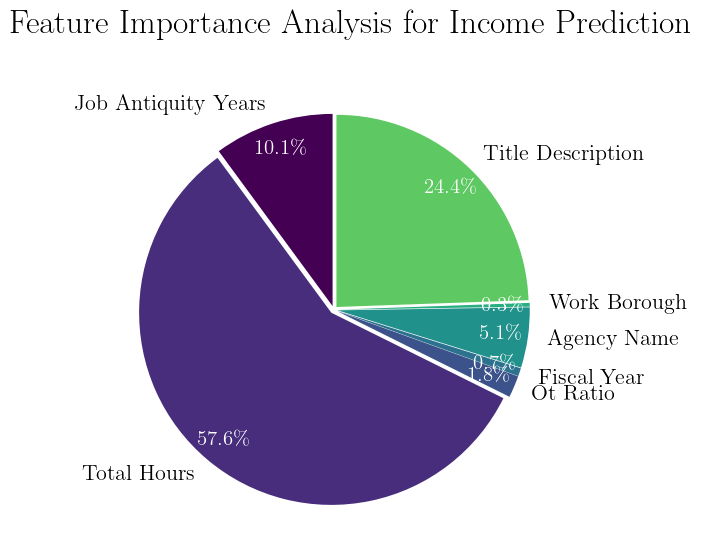


IMPORTANCE BY FEATURE CATEGORY

📊 Numerical features (job_antiquity_years, total_hours, ot_ratio): 69.50%

📊 Categorical features (fiscal_year, agency, borough, title): 30.50%


In [16]:
print("=" * 50)
print("STEP 8: FEATURE IMPORTANCE")
print("=" * 50)

# Rebuild feature names
feature_names = numerical_features.copy()

# Get categorical feature names from one-hot encoder
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names.extend(cat_feature_names)

# Get feature importances
importances = rf_model.feature_importances_

# Create importance DataFrame
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# ========== PLOT ==========
fig, ax = plt.subplots(figsize=(8, 6)) 

# Feature category breakdown
categories = []
category_importances = []

# Add each numerical feature individually
for num_feature in numerical_features:
    # Find the index of this numerical feature
    idx = feature_names.index(num_feature)
    categories.append(num_feature)
    category_importances.append(importances[idx])

# Add each categorical feature group
for cat_feature in categorical_features:
    mask = [f.startswith(cat_feature) for f in feature_names]
    cat_importance = sum(importances[i] for i, m in enumerate(mask) if m)
    categories.append(cat_feature)
    category_importances.append(cat_importance)

# Create pie chart with better labels
cat_labels = [c.replace('_', ' ').title() for c in categories]
# Use a larger color palette since we have more categories
colors_pie = plt.cm.viridis(np.linspace(0.0, 0.75, len(categories)))

# Only explode if we have reasonable number of slices (avoid too many explosions)
explode = [0.02] * len(categories) if len(categories) <= 8 else [0] * len(categories)

wedges, texts, autotexts = ax.pie(category_importances, 
                                  labels=cat_labels,
                                  autopct='%1.1f%%',
                                  colors=colors_pie,
                                  startangle=90,
                                  explode=explode,
                                  pctdistance=0.86,  # Increased from default 0.6
                                  )

# Style the pie chart text
for text in texts:
    text.set_fontsize(16)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(15)


plt.suptitle('Feature Importance Analysis for Income Prediction', fontweight='bold', y=0.95)
plt.tight_layout()
plt.savefig('feature_importance_breakdown.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


# Print summary statistics
print("\n" + "=" * 50)
print("IMPORTANCE BY FEATURE CATEGORY")
print("=" * 50)

numerical_importance = sum(importances[i] for i in range(len(numerical_features)))
print(f"\n📊 Numerical features (job_antiquity_years, total_hours, ot_ratio): {numerical_importance:.2%}")

categorical_importance = 1 - numerical_importance 
print(f"\n📊 Categorical features (fiscal_year, agency, borough, title): {categorical_importance:.2%}")


STEP 9: GLOBAL MODEL PERFORMANCE


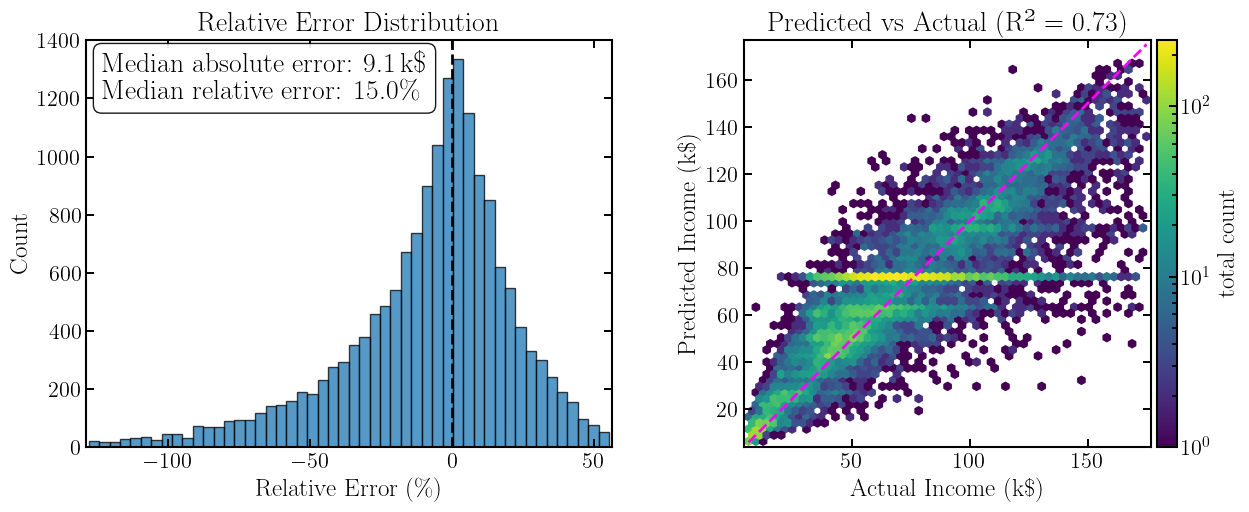

In [17]:
print("=" * 50)
print("STEP 9: GLOBAL MODEL PERFORMANCE")
print("=" * 50)

# ==========================================
# Residuals and relative errors
# ==========================================
residuals = y_test - y_pred_test

# Relative error in %
relative_errors = 100 * residuals / y_test

# Percentile limits for visualization
lower_clip = np.percentile(relative_errors, 0.5)
upper_clip = np.percentile(relative_errors, 99.5)

# ==========================================
# Create figure
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# =========================================================
# LEFT: Relative error distribution
# =========================================================

axes[0].hist(
    relative_errors,
    bins=50,
    range=(lower_clip, upper_clip),
    edgecolor='black',
    alpha=0.75
)

# Reference line at zero error
axes[0].axvline(
    0,
    linestyle='--',
    linewidth=2,
    color='black'
)

axes[0].set_xlabel(r'Relative Error (\%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Relative Error Distribution')

axes[0].set_xlim(lower_clip - 1, upper_clip + 1)

# =========================================================
# Summary statistics
# =========================================================

median_abs_error_k = np.median(np.abs(residuals))
median_abs_relative_error = np.median(np.abs(relative_errors))

stats_text = (
    rf"Median absolute error: "
    rf"{median_abs_error_k:,.1f}\,k\$" "\n"
    rf"Median relative error: "
    rf"{median_abs_relative_error:.1f}\%"
)

# Add annotation box
axes[0].text(
    0.03,
    0.97,
    stats_text,
    transform=axes[0].transAxes,
    ha='left',
    va='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.9
    )
)

# =========================================================
# RIGHT: Predicted vs Actual
# =========================================================
hb = axes[1].hexbin(
    y_test,
    y_pred_test,
    gridsize=55,
    bins='log',
    mincnt=1
)

# Identity line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())

axes[1].plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    linewidth=2,
    color="magenta"
)

axes[1].set_xlabel(r'Actual Income (k\$)')
axes[1].set_ylabel(r'Predicted Income (k\$)')
axes[1].set_title(f'Predicted vs Actual (R² = {test_r2:.2f})')

# Equal aspect ratio
axes[1].set_aspect('equal')
axes[1].set_xlim(4, 177)
axes[1].set_ylim(4, 177)

# Colorbar
cb = fig.colorbar(hb, ax=axes[1], pad=0.01)
cb.set_label('total count')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

STEP 10: MODEL PERFORMANCE BY CATEGORY


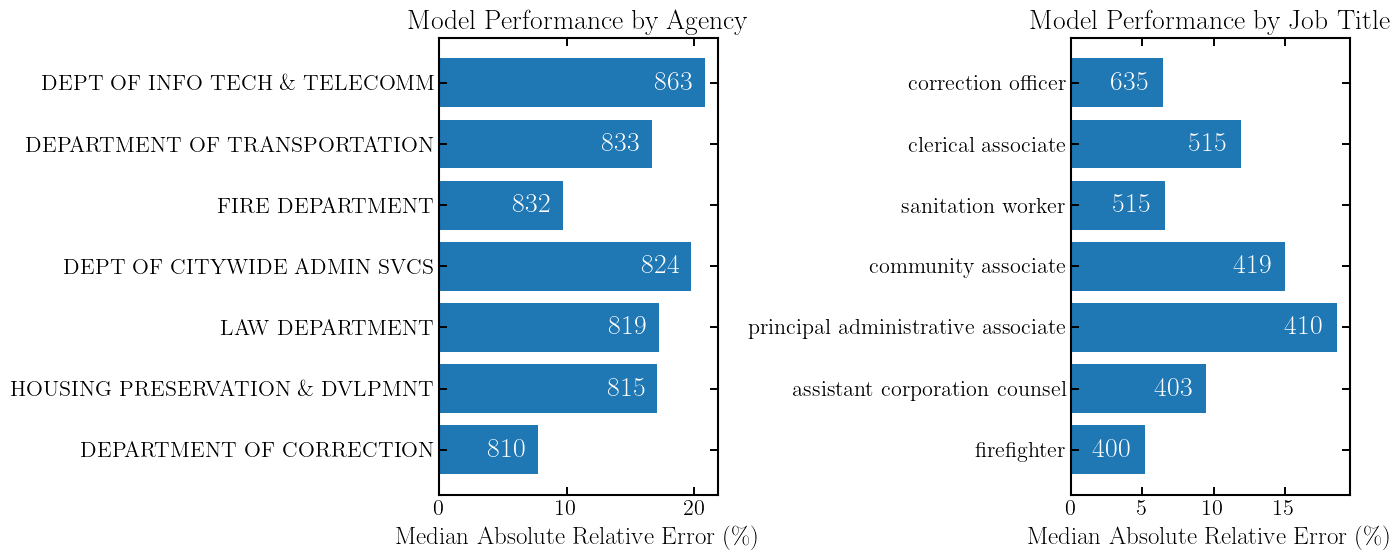

In [18]:
print("=" * 50)
print("STEP 10: MODEL PERFORMANCE BY CATEGORY")
print("=" * 50)

# =========================================================
# Build error dataframe
# =========================================================

error_df = pd.DataFrame({
    'actual_k': y_test,
    'predicted_k': y_pred_test,
    'residual_k': residuals,
    'relative_error_pct': relative_errors,
    'abs_relative_error_pct': np.abs(relative_errors),
    'agency': X_test['agency_name'],
    'title': X_test['title_description']
})

# =========================================================
# Helper function for LaTeX labels
# =========================================================

def latex_escape(text):

    replacements = {
        '&': r'\&',
        '%': r'\%',
        '$': r'\$',
        '#': r'\#',
        '_': r'\_'
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    return text

# =========================================================
# Summary statistics
# =========================================================

agency_summary = (
    error_df
    .groupby('agency')
    .agg(
        median_abs_error_pct=('abs_relative_error_pct', 'median'),
        n_samples=('agency', 'size')
    )
    .sort_values('n_samples', ascending=False)
    .head(7)
)

title_summary = (
    error_df
    .groupby('title')
    .agg(
        median_abs_error_pct=('abs_relative_error_pct', 'median'),
        n_samples=('title', 'size')
    )
    .sort_values('n_samples', ascending=False)
    .head(7)
)

# =========================================================
# Clean labels
# =========================================================

agency_labels = [
    latex_escape(x)
    for x in agency_summary.index
]

title_labels = [
    latex_escape(x)
    for x in title_summary.index
]

# =========================================================
# Create plots
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =========================================================
# LEFT: Agencies
# =========================================================

bars1 = axes[0].barh(
    agency_labels,
    agency_summary['median_abs_error_pct']
)

axes[0].invert_yaxis()

axes[0].set_xlabel(r'Median Absolute Relative Error (\%)')
axes[0].set_title('Model Performance by Agency')

# Add sample counts inside bars
for bar, n in zip(bars1, agency_summary['n_samples']):

    width = bar.get_width()

    axes[0].text(
        width - 1.0,
        bar.get_y() + bar.get_height() / 2,
        f"{n:,}",
        ha='right',
        va='center',
        color='white',
        fontweight='bold'
    )

# =========================================================
# RIGHT: Titles
# =========================================================

bars2 = axes[1].barh(
    title_labels,
    title_summary['median_abs_error_pct']
)

axes[1].invert_yaxis()

axes[1].set_xlabel(r'Median Absolute Relative Error (\%)')
axes[1].set_title('Model Performance by Job Title')

# Add sample counts inside bars
for bar, n in zip(bars2, title_summary['n_samples']):

    width = bar.get_width()

    axes[1].text(
        width - 1.0,
        bar.get_y() + bar.get_height() / 2,
        f"{n:,}",
        ha='right',
        va='center',
        color='white',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()